In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
models_w_training = ["dinomaly","efficientad","draem"]
models = models_w_training + ["winclip","patchcore","padim"]
categories = ["bottle","capsule","hazelnut","metal_nut","pill","screw","toothbrush","transistor","zipper","cable","carpet","grid","leather","tile","wood"]

df_training = pd.concat([pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/resultats_finaux_mvtec_ad/{model}/{model}/{category}/metrics.csv").assign(model=model) 
                                    for model in models_w_training]).assign(category=category)
                         for category in categories])

df_training = df_training.groupby(["epoch","category","model"], as_index=False).first()

df_results= pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/resultats_finaux_mvtec_ad/{model}/mvtec_results.csv") for model in models])

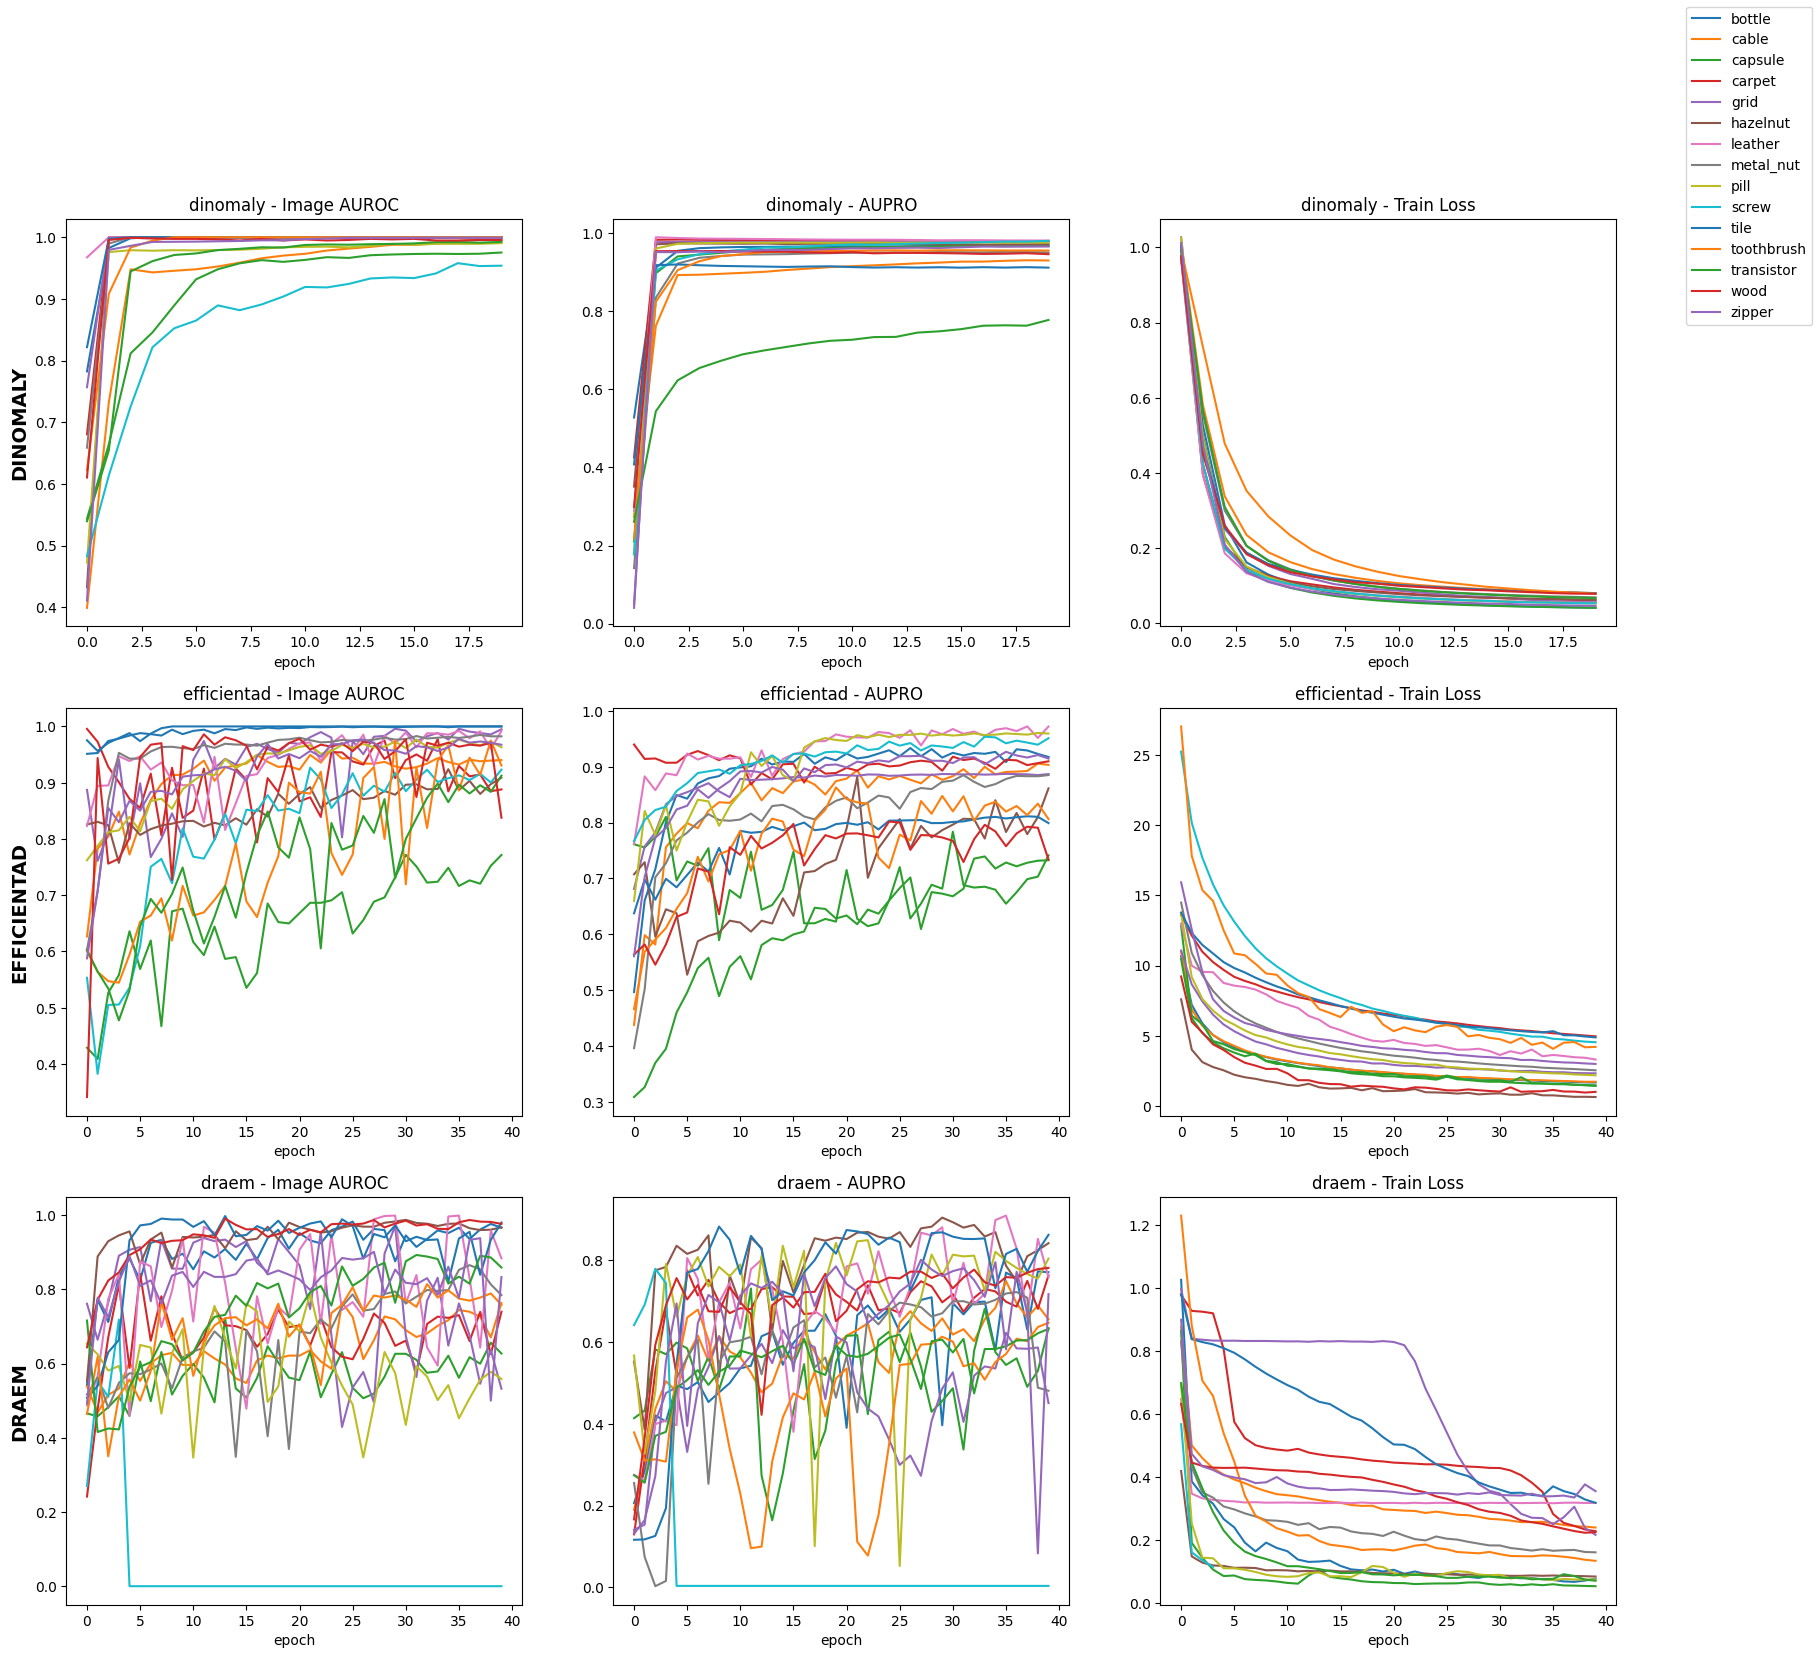

In [11]:
fig, axes = plt.subplots(len(models_w_training), 3, figsize=(20, 6 * len(models_w_training)))

if len(models_w_training) == 1:
    axes = axes.reshape(1, 3)

for i, model_name in enumerate(models_w_training):
    df_model = df_training[df_training.model == model_name]
    
    for name, group in df_model.groupby("category"):
        group.plot(x="epoch", y="AUROC", ax=axes[i, 0], label=name, legend=False)
        group.plot(x="epoch", y="AUPRO", ax=axes[i, 1], label=name, legend=False)
        group.plot(x="epoch", y="train_loss_epoch", ax=axes[i, 2], label=name, legend=False)

    axes[i, 0].set_ylabel(model_name.upper(), fontsize=14, fontweight='bold')
    axes[i, 0].set_title(f"{model_name} - Image AUROC")
    axes[i, 1].set_title(f"{model_name} - AUPRO")
    axes[i, 2].set_title(f"{model_name} - Train Loss")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels)
plt.show()

Text(120.72222222222221, 0.5, 'Modèle')

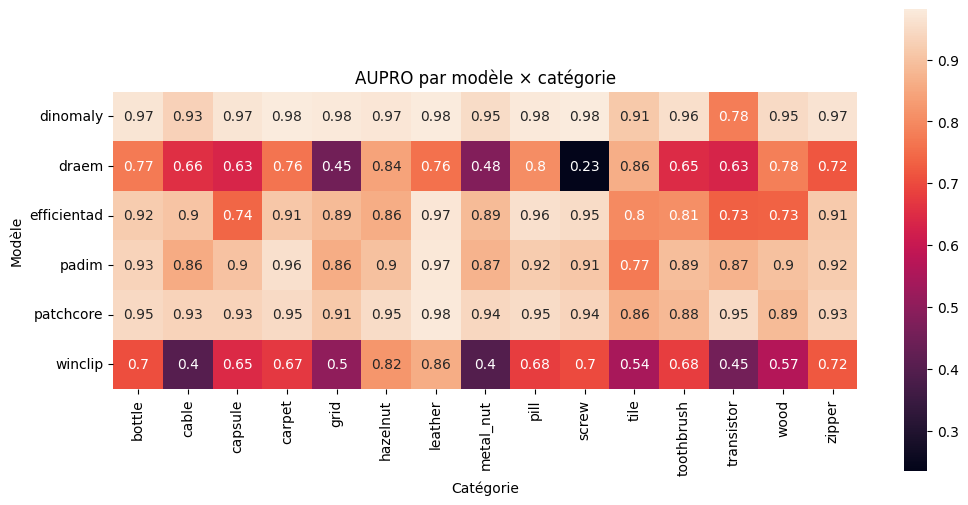

In [12]:
df_heatmap = df_results.copy()
df_heatmap = df_heatmap[["AUPRO","model","category"]]
df_heatmap = df_heatmap
df_heatmap = df_heatmap.pivot(columns="category", index="model", values="AUPRO")
plt.figure(figsize=(12,6))
plt.title("AUPRO par modèle × catégorie")
sns.heatmap(df_heatmap,annot=True,square=True)
plt.xlabel("Catégorie")
plt.ylabel("Modèle")

Text(120.72222222222221, 0.5, 'Modèle')

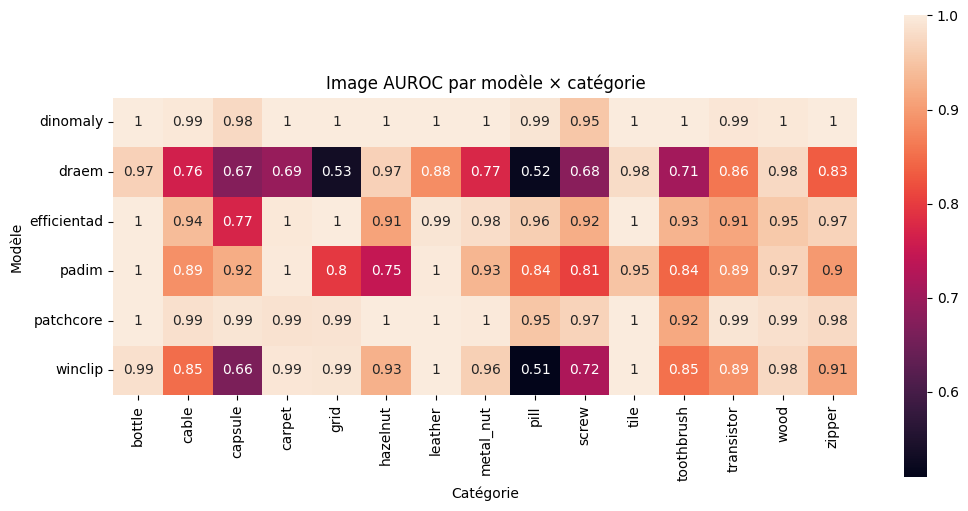

In [14]:
df_heatmap = df_results.copy()
df_heatmap = df_heatmap[["image_AUROC","model","category"]]
df_heatmap = df_heatmap
df_heatmap = df_heatmap.pivot(columns="category", index="model", values="image_AUROC")
plt.figure(figsize=(12,6))
plt.title("Image AUROC par modèle × catégorie")
sns.heatmap(df_heatmap,annot=True,square=True)
plt.xlabel("Catégorie")
plt.ylabel("Modèle")

Text(0.5, 1.0, "Temps d'inférence moyen par modèle × catégorie")

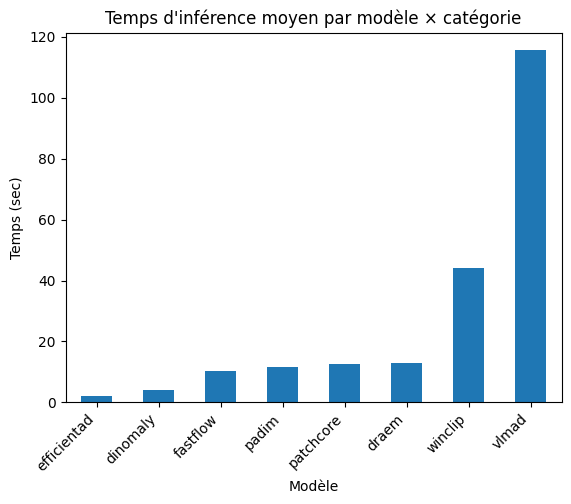

In [13]:
df_bar = df.copy()
df_bar = df_bar[["model","inference_time_sec"]]
df_bar.groupby("model").mean().sort_values("inference_time_sec").plot(kind="bar", legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Modèle")
plt.ylabel("Temps (sec)")
plt.title("Temps d'inférence moyen par modèle × catégorie")


Text(0.5, 0, 'Classes')

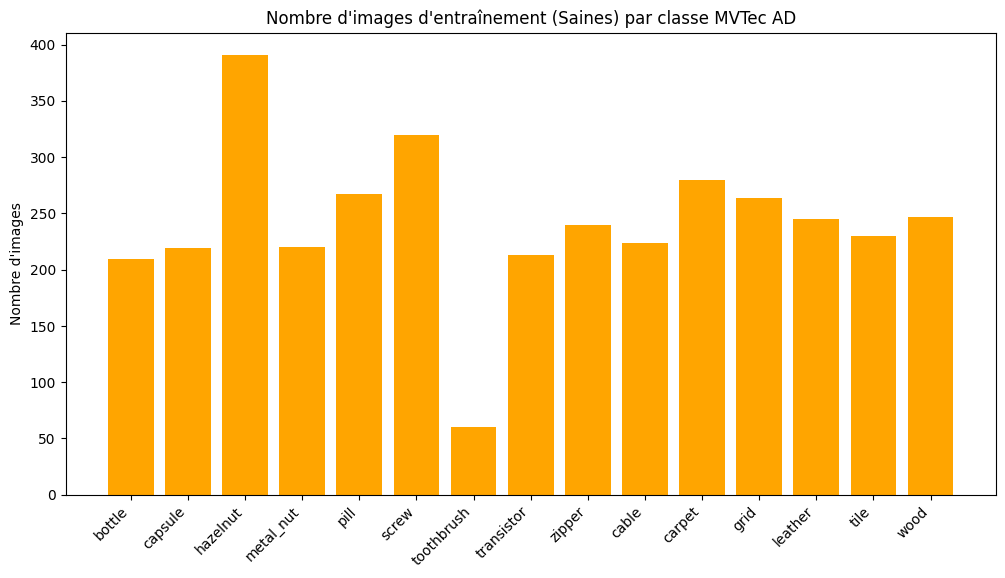

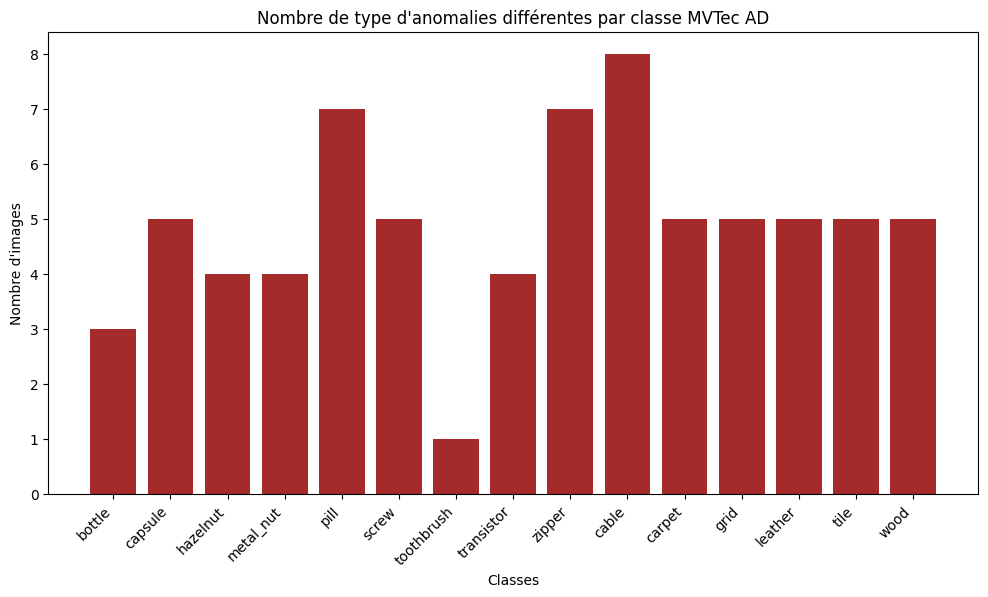

In [25]:
mvtec_train_counts = {
    "bottle": 209, "capsule": 219, "hazelnut": 391,
    "metal_nut": 220, "pill": 267, "screw": 320, "toothbrush": 60,
    "transistor": 213, "zipper": 240, "cable": 224, "carpet": 280, "grid": 264,
    "leather": 245, "tile": 230, "wood": 247
}

mvtec_anomaly_types_counts = {
    "bottle": 3,      # broken_large, broken_small, contamination
    "capsule": 5,     # crack, faulty_imprint, poke, scratch, squeeze
    "hazelnut": 4,    # crack, cut, hole, print
    "metal_nut": 4,   # bent, color, flip, scratch
    "pill": 7,        # combined, contamination, crack, faulty_imprint, pill_type, scratch, SIMULATED
    "screw": 5,       # manipulated_front, scratch_head, scratch_neck, thread_side, thread_top
    "toothbrush": 1,  # defective
    "transistor": 4,  # bent_lead, cut_lead, damaged_case, misplaced
    "zipper": 7,      # broken_teeth, combined, fabric_interior, fabric_border, rough, squeezed, twisted
    "cable": 8,       # bent, cable_swap, combined, cut, missing_cable, missing_wire, poke, twisted
    "carpet": 5,      # color, cut, hole, metal_contamination, thread
    "grid": 5,        # bent, broken, glue, metal_contamination, thread
    "leather": 5,     # color, cut, fold, glue, poke
    "tile": 5,        # crack, glue, oil, rough, scratch
    "wood": 5         # combined, hole, liquid, scratch, color
}

categories = list(mvtec_train_counts.keys())
counts = list(mvtec_train_counts.values())
anomaly_types_counts = list(mvtec_anomaly_types_counts.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, counts,color="orange")
plt.xticks(rotation=45, ha='right')
plt.title("Nombre d'images d'entraînement (Saines) par classe MVTec AD")
plt.ylabel("Nombre d'images")

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, anomaly_types_counts,color="brown")
plt.xticks(rotation=45, ha='right')
plt.title("Nombre de type d'anomalies différentes par classe MVTec AD")
plt.ylabel("Nombre d'images")
plt.xlabel("Classes")